**Thesis**: A Comparative Study of Large Language Models for Financial Sentiment Analysis and Their Predictive Potential for Short-Term Stock Price Movement

**Component: Experiment 1** — Dataset Preparation

**Description:** This notebook loads and checks the Financial PhraseBank dataset (Malo et al., 2014) for use in Experiment 1.

It performs class distribution analysis and prepares the dataset for sentiment classification benchmarking across all four LLM models.

In [1]:
# Install all required libraries — Dataset Preparation

!pip install -q transformers datasets torch
!pip install -q yfinance pandas matplotlib seaborn

print("All libraries installed successfully.")

All libraries installed successfully.


In [2]:
# Import required libraries for dataset preparation

import pandas as pd
import numpy as np
import torch
import warnings

import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")

# Check GPU
print(f"PyTorch version : {torch.__version__}")
print(f"CUDA available  : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU detected    : {torch.cuda.get_device_name(0)}")
else:
    print("No GPU detected")

PyTorch version : 2.10.0+cu128
CUDA available  : True
GPU detected    : Tesla T4


Add the API Key from Hugging Face using "Add New Secret" in Google Colab

In [3]:
# Connect to Hugging Face
from google.colab import userdata
from huggingface_hub import login

hf_token = userdata.get("HF_TOKEN")
login(token=hf_token)

print("Hugging Face login successful.")

Hugging Face login successful.


In [4]:
# Load Financial PhraseBank using the Parquet branch
# Using sentences_50agree (Full Dataset)

from huggingface_hub import hf_hub_download

file_path = hf_hub_download(
    repo_id="takala/financial_phrasebank",
    filename="sentences_50agree/train-00000-of-00001.parquet",
    repo_type="dataset",
    revision="0dd3028d70cbd18ded8887e65e83343b03a50482",
    token=hf_token
)

df_fpb = pd.read_parquet(file_path)

print("Dataset loaded successfully.")
print(f"Total sentences : {len(df_fpb)}")
print(f"Columns         : {list(df_fpb.columns)}")
print(f"\nFirst 3 rows:")
print(df_fpb.head(3))

sentences_50agree/train-00000-of-00001.p(…):   0%|          | 0.00/390k [00:00<?, ?B/s]

Dataset loaded successfully.
Total sentences : 4846
Columns         : ['sentence', 'label']

First 3 rows:
                                            sentence  label
0  According to Gran , the company has no plans t...      1
1  Technopolis plans to develop in stages an area...      1
2  The international electronic industry company ...      0


In [5]:
# Map numeric labels to text sentiment
# 0 = negative, 1 = neutral, 2 = positive

label_map = {0: "negative", 1: "neutral", 2: "positive"}
df_fpb["sentiment"] = df_fpb["label"].map(label_map)

# Check class distribution
print("=" * 45)
print("Financial PhraseBank — Class Distribution")
print("=" * 45)

counts = df_fpb["sentiment"].value_counts()
total = len(df_fpb)

for sentiment in ["positive", "negative", "neutral"]:
    count = counts[sentiment]
    print(f"  {sentiment:<12}: {count:>5}  ({count/total*100:.1f}%)")

print(f"  {'TOTAL':<12}: {total:>5}")
print("=" * 45)

Financial PhraseBank — Class Distribution
  positive    :  1363  (28.1%)
  negative    :   604  (12.5%)
  neutral     :  2879  (59.4%)
  TOTAL       :  4846


In [6]:
# Print 5 sample sentences per class to inspect quality of labels

for sentiment in ["positive", "negative", "neutral"]:
    print(f"\n── 5 samples: {sentiment.upper()} ──")
    samples = df_fpb[df_fpb["sentiment"] == sentiment]["sentence"].sample(5, random_state=42)
    for i, s in enumerate(samples, 1):
        print(f"  {i}. {s}")


── 5 samples: POSITIVE ──
  1. The new agreement , which expands a long-established cooperation between the companies , involves the transfer of certain engineering and documentation functions from Larox to Etteplan .
  2. ( ADP News ) - Finnish handling systems provider Cargotec Oyj ( HEL : CGCBV ) announced on Friday it won orders worth EUR 10 million ( USD 13.2 m ) to deliver linkspans to Jordan , Morocco and Ireland .
  3. The world 's biggest magazine paper maker said the program to improve efficiency will include closing several of its least competitive mills and would cover all the company 's operations resulting in annual savings of some euro200 million US$ 240 million .
  4. a January 11 , 2010 EPHC board of directors has approved an increase in the quarterly dividend from $ 0.03 to $ 0.05 per share .
  5. With this appointment Kaupthing Bank aims to further co-ordinate Capital Markets activities within the Group and to improve the overall service to clients .

── 5 samples: 

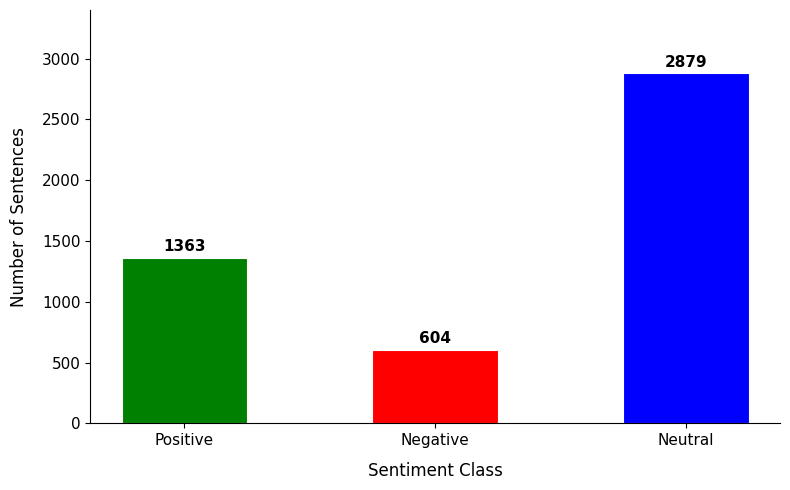

In [7]:
# Sentiment label distribution chart — Financial PhraseBank

sentiments = ["Positive", "Negative", "Neutral"]
counts_ordered = [1363, 604, 2879]
colors = ["green", "red", "blue"]

fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.bar(sentiments, counts_ordered, color=colors,
              width=0.5, edgecolor="white", linewidth=0.8)

for bar, count in zip(bars, counts_ordered):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 30,
        str(count),
        ha="center", va="bottom",
        fontsize=11, fontweight="bold"
    )

ax.set_xlabel("Sentiment Class", fontsize=12, labelpad=10)
ax.set_ylabel("Number of Sentences", fontsize=12, labelpad=10)
ax.set_ylim(0, 3400)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.tick_params(axis="both", labelsize=11)

plt.tight_layout()
plt.show()